In [1]:
import json, shutil
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
REPO_ROOT = Path('../..').resolve()
OUT_DIR   = REPO_ROOT/'outputs'/'thesis_figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi':150,'savefig.dpi':150,'font.size':11,
    'axes.titlesize':12,'axes.labelsize':11,'legend.fontsize':10,
    'figure.facecolor':'white','axes.grid':True,'grid.alpha':0.3})
COLORS = plt.cm.Set2.colors
print(f'Output: {OUT_DIR}')


Output: D:\TrashDetectionSystem\outputs\thesis_figures


---
## T2 - Metrici Clasificator B2 per-clasa


In [3]:
eval_path = REPO_ROOT/'runs'/'classify_eval'/'parks-cls-B2'/'summary_test.json'
if not eval_path.exists():
    print(f'Rulati mai intai 02_evaluate_classifier.ipynb  ->  {eval_path}')
else:
    with open(eval_path) as f: b2=json.load(f)
    CLASSES=['glass','metal','other','paper','plastic']
    t2_rows=[]
    for cls in CLASSES:
        pc=b2['per_class'].get(cls,{})
        t2_rows.append({'Clasa':cls,'Precision':pc.get('precision',0),
                        'Recall':pc.get('recall',0),'F1':pc.get('f1',0),
                        'Support':pc.get('support',0),'AUC':pc.get('auc',None)})
    df_t2=pd.DataFrame(t2_rows).set_index('Clasa')
    print(f'Accuracy   : {b2["accuracy"]:.4f}')
    print(f'Macro F1   : {b2["macro_f1"]:.4f}')
    print(f'Weighted F1: {b2.get("weighted_f1",0):.4f}')
    print(f'Top-5 Acc  : {b2.get("top5_accuracy",0):.4f}')
    display(df_t2.style
        .highlight_max(subset=['F1','AUC'],color='#90EE90')
        .highlight_min(subset=['F1'],color='#FFB6B6')
        .format({'Precision':'{:.3f}','Recall':'{:.3f}','F1':'{:.3f}','AUC':'{:.3f}'}))


Accuracy   : 0.9144
Macro F1   : 0.8788
Weighted F1: 0.9143
Top-5 Acc  : 1.0000


,Precision,Recall,F1,Support,AUC
Clasa,,,,,
glass,0.900,0.882,0.891,51,0.986
metal,0.864,0.927,0.894,41,0.974
other,0.733,0.733,0.733,15,0.989
paper,0.951,0.970,0.961,101,0.994
plastic,0.956,0.878,0.915,49,0.990


---
## F1 - Curbe Training A4 (mAP50, P, R, Losses)


---
## F2 - Curbe Training B2


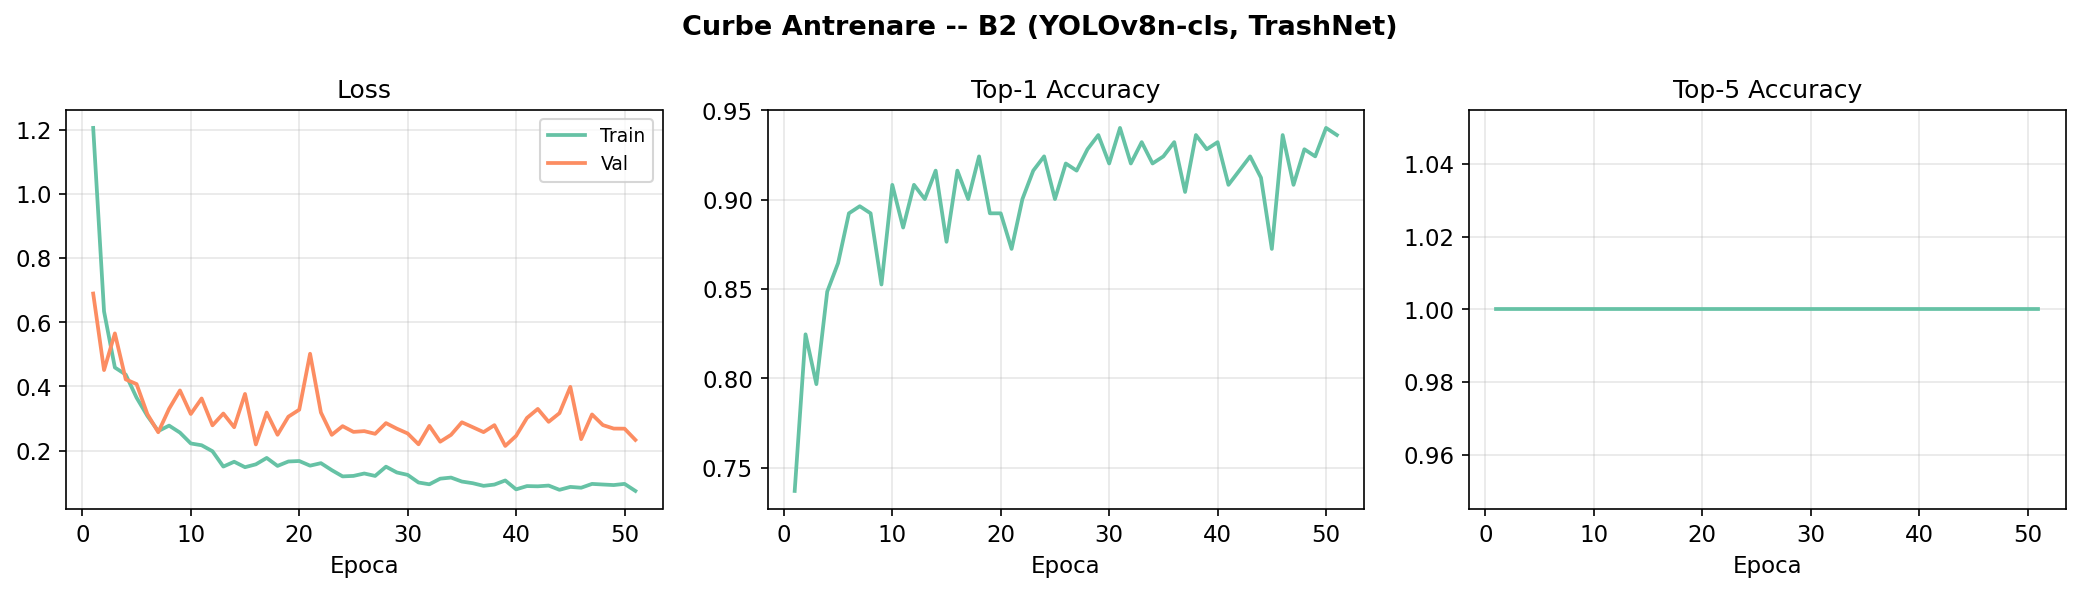

Salvat: D:\TrashDetectionSystem\outputs\thesis_figures\F2_training_curves_B2.png


In [5]:
csv_b2=REPO_ROOT/'runs'/'classify'/'parks-cls-B2'/'results.csv'
df_b2=pd.read_csv(csv_b2); df_b2.columns=df_b2.columns.str.strip()
ep_c=df_b2['epoch']
fig,axes=plt.subplots(1,3,figsize=(14,4))
fig.suptitle('Curbe Antrenare -- B2 (YOLOv8n-cls, TrashNet)',fontsize=13,fontweight='bold')
cls_plots=[('train/loss','val/loss','Loss',axes[0]),
           ('metrics/accuracy_top1',None,'Top-1 Accuracy',axes[1]),
           ('metrics/accuracy_top5',None,'Top-5 Accuracy',axes[2])]
for tcol,vcol,title,ax in cls_plots:
    if tcol in df_b2.columns: ax.plot(ep_c,df_b2[tcol],color=COLORS[0],lw=1.8,label='Train' if vcol else title)
    if vcol and vcol in df_b2.columns: ax.plot(ep_c,df_b2[vcol],color=COLORS[1],lw=1.8,label='Val')
    ax.set_title(title); ax.set_xlabel('Epoca')
    if vcol: ax.legend(fontsize=9)
plt.tight_layout()
out=OUT_DIR/'F2_training_curves_B2.png'
plt.savefig(str(out),bbox_inches='tight'); plt.show(); print(f'Salvat: {out}')


---
## F3 - Confusion Matrix B2


Copied: D:\TrashDetectionSystem\outputs\thesis_figures\F3_confusion_matrix_B2.png


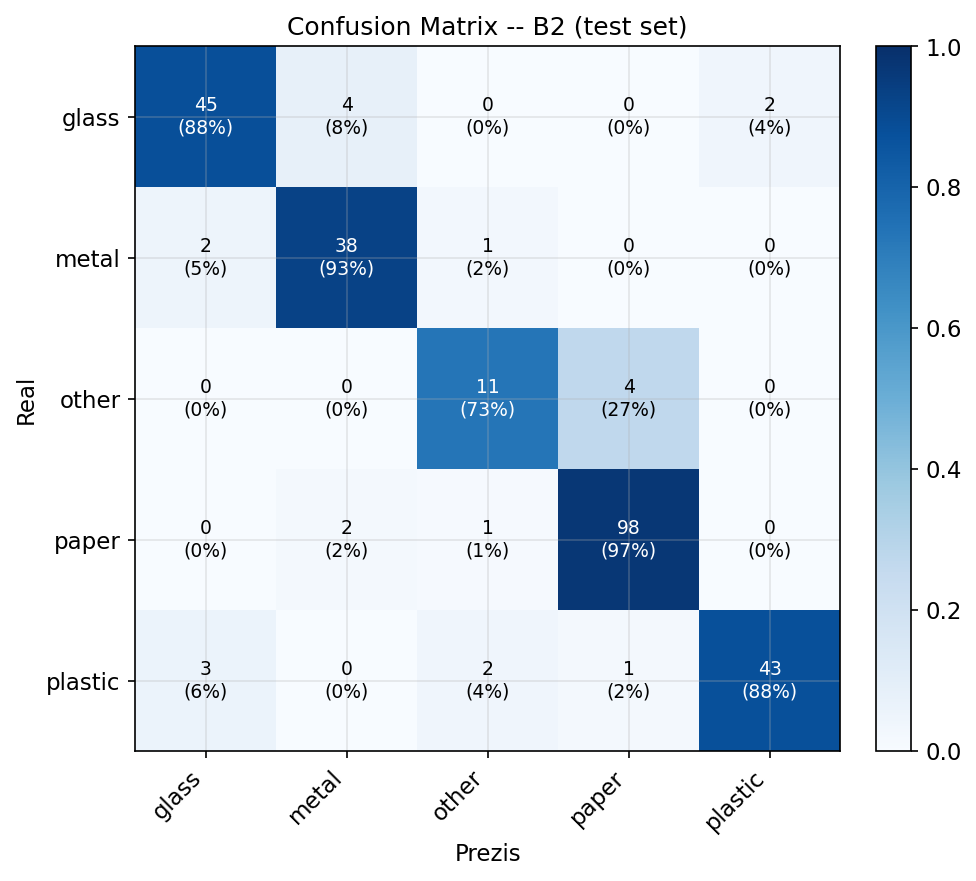

In [6]:
from IPython.display import Image as IPImage, display
# Incarca confusion matrix din evaluate_classifier daca exista
src1=REPO_ROOT/'runs'/'classify_eval'/'parks-cls-B2'/f'confusion_matrix_test.png'
src2=REPO_ROOT/'runs'/'classify'/'parks-cls-B2'/'confusion_matrix_normalized.png'
src=src1 if src1.exists() else src2
if src.exists():
    dst=OUT_DIR/'F3_confusion_matrix_B2.png'
    shutil.copy2(src,dst); print(f'Copied: {dst}')
    display(IPImage(str(dst),width=600))
else:
    print('Rulati 02_evaluate_classifier.ipynb mai intai')


---
## F4 - F1 per clasa B2


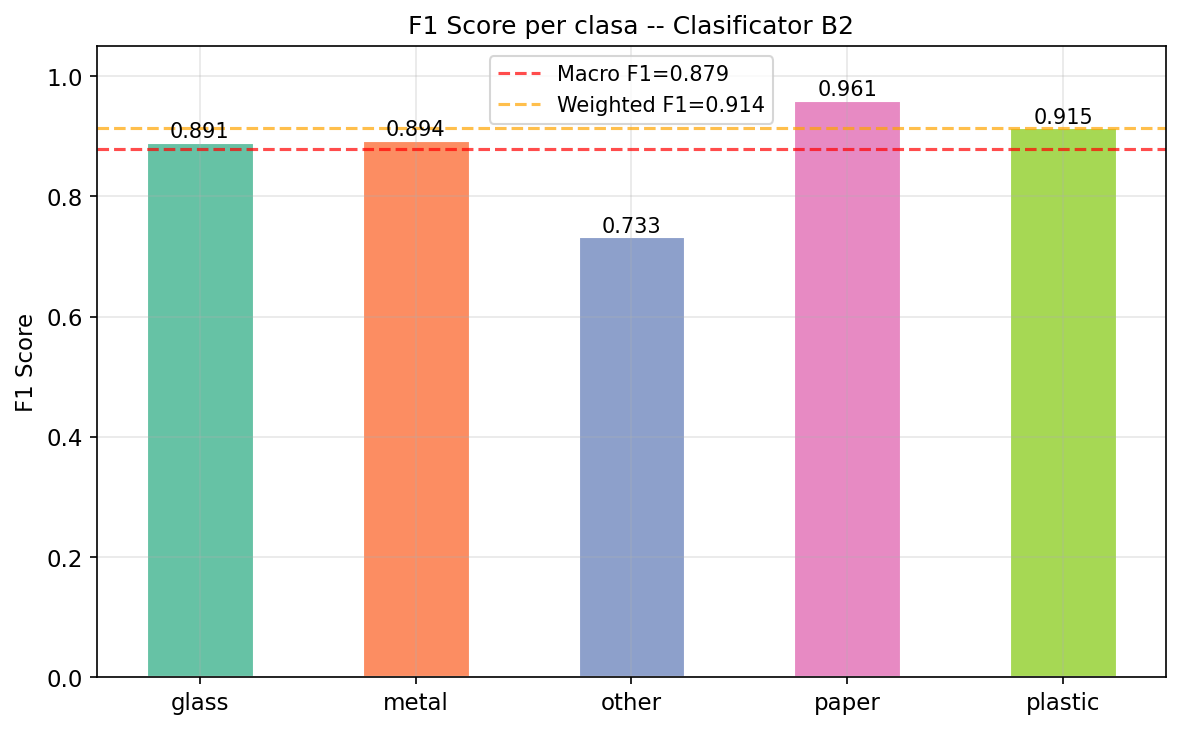

Salvat: D:\TrashDetectionSystem\outputs\thesis_figures\F4_f1_per_class_B2.png


In [7]:
if eval_path.exists():
    f1_vals=[b2['per_class'][c]['f1'] for c in CLASSES]
    x=np.arange(len(CLASSES)); width=0.5
    fig,ax=plt.subplots(figsize=(8,5))
    bars=ax.bar(x,f1_vals,width,color=[COLORS[i%len(COLORS)] for i in range(len(CLASSES))],
                edgecolor='white',lw=1.5)
    ax.axhline(b2['macro_f1'],color='red',ls='--',alpha=0.7,
               label=f'Macro F1={b2["macro_f1"]:.3f}')
    ax.axhline(b2.get('weighted_f1',0),color='orange',ls='--',alpha=0.7,
               label=f'Weighted F1={b2.get("weighted_f1",0):.3f}')
    ax.set_xticks(x); ax.set_xticklabels(CLASSES)
    ax.set_ylabel('F1 Score'); ax.set_ylim(0,1.05)
    ax.set_title('F1 Score per clasa -- Clasificator B2')
    ax.legend()
    ax.bar_label(bars,fmt='%.3f',fontsize=10)
    plt.tight_layout()
    out=OUT_DIR/'F4_f1_per_class_B2.png'
    plt.savefig(str(out),bbox_inches='tight'); plt.show(); print(f'Salvat: {out}')


---
## F5 - Distributie dataset TrashNet


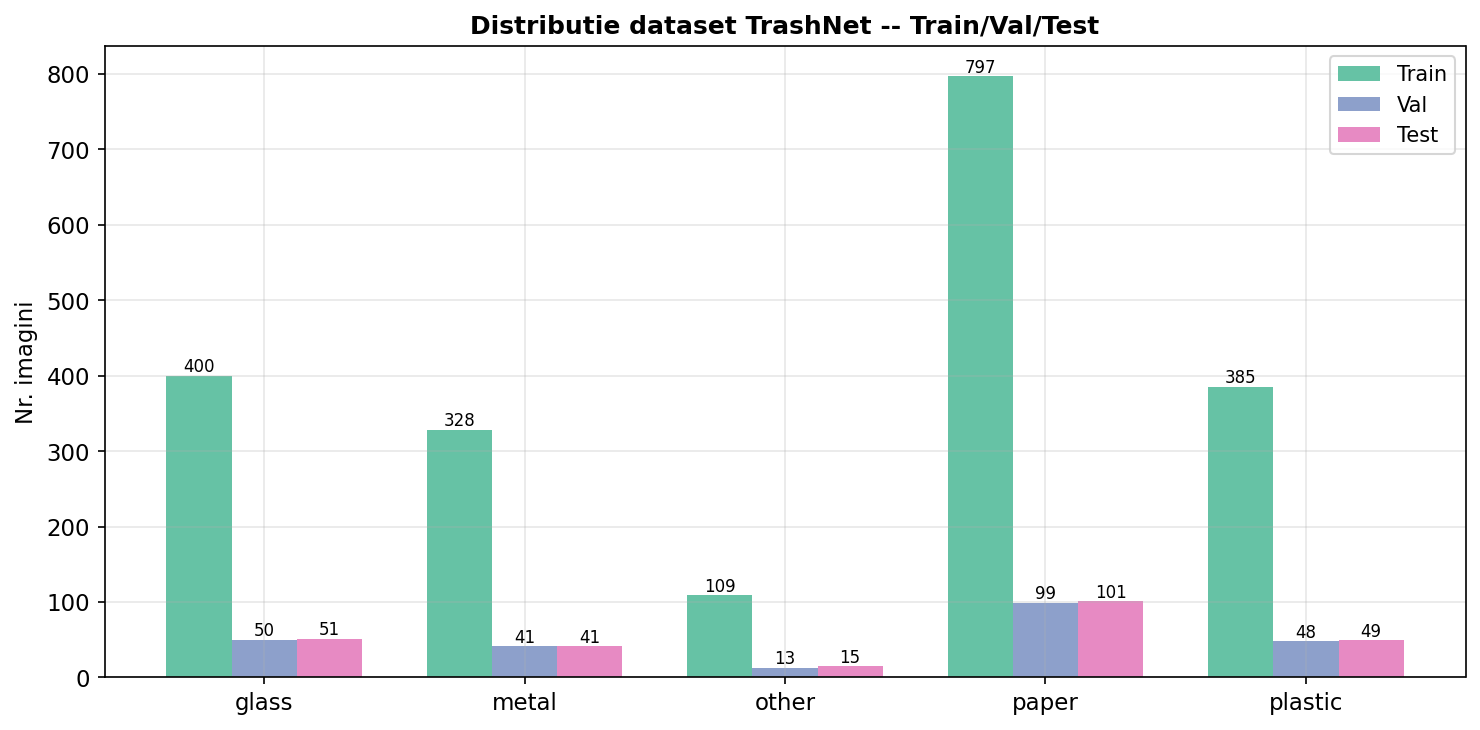

Salvat: D:\TrashDetectionSystem\outputs\thesis_figures\F5_dataset_distribution_trashnet.png


In [8]:
cls_root=REPO_ROOT/'datasets'/'trashnet_cls'
splits=['train','val','test']; dist={s:{} for s in splits}
for s in splits:
    for cls in CLASSES:
        p=cls_root/s/cls
        dist[s][cls]=len(list(p.glob('*'))) if p.exists() else 0
x=np.arange(len(CLASSES)); width=0.25
split_colors=[COLORS[0],COLORS[2],COLORS[3]]
fig,ax=plt.subplots(figsize=(10,5))
for i,(s,offset,color) in enumerate(zip(splits,[-width,0,width],split_colors)):
    vals=[dist[s][c] for c in CLASSES]
    bars=ax.bar(x+offset,vals,width,label=s.capitalize(),color=color)
    ax.bar_label(bars,fontsize=8)
ax.set_title('Distributie dataset TrashNet -- Train/Val/Test',fontweight='bold')
ax.set_ylabel('Nr. imagini'); ax.set_xticks(x); ax.set_xticklabels(CLASSES)
ax.legend()
plt.tight_layout()
out=OUT_DIR/'F5_dataset_distribution_trashnet.png'
plt.savefig(str(out),bbox_inches='tight'); plt.show(); print(f'Salvat: {out}')


---
## F6 - Distributie materiale pipeline A4+B2


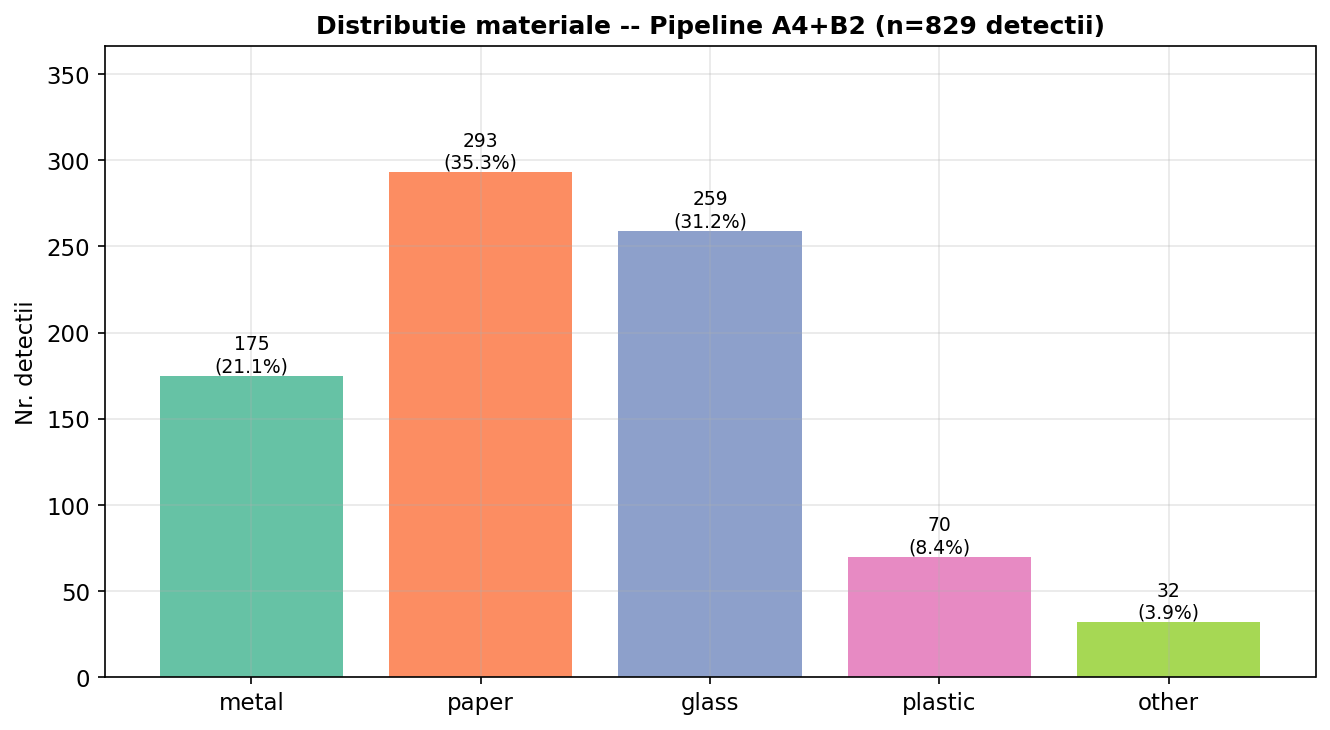

Salvat: D:\TrashDetectionSystem\outputs\thesis_figures\F6_material_distribution_A4B2.png


In [9]:
csv_p=REPO_ROOT/'outputs'/'two_stage_demo'/'detections.csv'
if csv_p.exists():
    import csv
    from collections import Counter
    mat_cnt=Counter()
    with open(csv_p) as f:
        for row in csv.DictReader(f): mat_cnt[row.get('material',row.get('material_name','?'))]+=1
    mats=list(mat_cnt.keys()); cnts=list(mat_cnt.values()); tot=sum(cnts)
    fig,ax=plt.subplots(figsize=(9,5))
    bars=ax.bar(mats,cnts,color=COLORS[:len(mats)])
    ax.bar_label(bars,labels=[f'{v}\n({v/tot*100:.1f}%)' for v in cnts],fontsize=9)
    ax.set_title(f'Distributie materiale -- Pipeline A4+B2 (n={tot} detectii)',fontweight='bold')
    ax.set_ylabel('Nr. detectii'); ax.set_ylim(0,max(cnts)*1.25)
    plt.tight_layout()
    out=OUT_DIR/'F6_material_distribution_A4B2.png'
    plt.savefig(str(out),bbox_inches='tight'); plt.show(); print(f'Salvat: {out}')
else:
    print('Rulati 05_inference_demo.ipynb mai intai')


---
## F7 - Speed Benchmark per stage


---
## Sumar fisiere generate


In [12]:
print(f'Figuri salvate in: {OUT_DIR}\n')
for fp in sorted(OUT_DIR.iterdir()):
    size_kb=fp.stat().st_size/1024
    print(f'  {fp.name:<55} {size_kb:6.1f} KB')


Figuri salvate in: D:\TrashDetectionSystem\outputs\thesis_figures

  F1_training_curves_A4.png                                204.2 KB
  F2_training_curves_B2.png                                 92.0 KB
  F3_confusion_matrix_B2.png                                74.6 KB
  F4_f1_per_class_B2.png                                    42.4 KB
  F5_dataset_distribution_trashnet.png                      43.1 KB
  F6_material_distribution_A4B2.png                         43.7 KB
  F7_speed_benchmark.png                                    50.4 KB
  F8_detector_evolution_mAP50_F1.png                        58.6 KB
